# 분석 대상 기사

- 제목 : '서울 유주택 신혼부부 10쌍 중 3쌍, 집값 6억 넘었다…대출 3억 이상도 8년새 4배 늘어'
- 매체 : 경향신문 (2026-09-28)
- 원문 : https://n.news.naver.com/mnews/article/032/0003472827

---
## 0. 준비

### 라이브러리 및 형태소 분석기 설정

In [2]:
import re
from collections import Counter

import requests
from bs4 import BeautifulSoup
from IPython.display import Markdown, display

import nltk
import MeCab
from konlpy.tag import Mecab

nltk.download('punkt_tab', quiet=True)      # nltk 문장/단어 토큰화 모델

DICPATH = 'C:/mecab/mecab-ko-dic'
mecab  = Mecab(dicpath=DICPATH)             # konlpy 래퍼
tagger = MeCab.Tagger(f'-d {DICPATH}')      # mecab 원본

print(mecab.pos('형태소 분석기'))

[('형태소', 'NNG'), ('분석기', 'NNG')]


### 기사 수집

네이버 뉴스 기사 페이지의 구조

| 요소 | CSS 선택자 |
|---|---|
| 제목 | `#title_area` |
| 언론사 | `a.media_end_head_top_logo img` 의 `alt` |
| 입력 시각 | `span.media_end_head_info_datestamp_time` 의 `data-date-time` |
| 기자 | `span.byline_s` |
| 본문 | `#dic_area` |

In [3]:
url = 'https://n.news.naver.com/mnews/article/032/0003472827'
response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
soup = BeautifulSoup(response.text, 'html.parser')

title  = soup.select_one('#title_area').get_text(strip=True)
press  = soup.select_one('a.media_end_head_top_logo img')['alt']
date   = soup.select_one('span.media_end_head_info_datestamp_time')['data-date-time']
byline = soup.select_one('span.byline_s').get_text(strip=True)

print('제목   :', title)
print('언론사 :', press, '/', date)
print('기자   :', byline)

제목   : 서울 유주택 신혼부부 10쌍 중 3쌍, 집값 6억 넘었다…대출 3억 이상도 8년새 4배 늘어
언론사 : 경향신문 / 2026-09-28 15:12:00
기자   : 박상영 기자 sypark@kyunghyang.com


### 본문 정제

- 본문 영역 안의 사진과 사진 설명(캡션)은 기사 문장이 아니므로 분리하여 따로 보관
- 문단은 `<br>` 태그로 나뉘어 있으므로 줄바꿈(`\n`)으로 바꾸어 문단 구분 보존

In [4]:
body = soup.select_one('#dic_area')

caption = body.select_one('em.img_desc').get_text(strip=True)
for photo in body.select('span.end_photo_org'):
    photo.decompose()

for br in body.find_all('br'):
    br.replace_with('\n')

paragraphs = [p.strip() for p in body.get_text().split('\n') if p.strip()]
text = '\n'.join(paragraphs)

print('사진 캡션 :', caption)
print('문단 수   :', len(paragraphs), '/ 글자 수 :', len(text))
print()
print(text)

사진 캡션 : 남산에서 바라본 아파트 단지. 2026.07.27. 김정근기자
문단 수   : 7 / 글자 수 : 1251

서울에 집을 보유한 신혼부부 10쌍 중 3쌍의 주택 공시가격 총액이 6억원을 넘는 것으로 나타났다. 서울 신혼부부의 6억원 초과 아파트 보유 비중은 크게 늘고, 대출잔액이 3억원이 넘는 신혼부부 비중도 8년만에 4배 가량 커졌다. 자산 격차가 더 벌어지는 모습이다.
28일 국가데이터처의 ‘초혼(5년 이내) 신혼부부 특성별 주택자산 가액별 신혼부부 수’ 통계를 보면 2024년 서울에 거주하는 유주택 신혼부부 4만8989쌍 가운데 보유 주택의 공시가격 총액이 6억원을 초과한 부부는 1만5368쌍으로 31.4%를 차지했다. 공시가격 6억원에 당시 공동주택 현실화율(69%)을 적용해 역산하면 시세 기준으로는 대략 8억원대 후반에 해당한다.
6억원을 초과하는 주택자산을 보유한 비율은 서울이 유독 높았다. 2024년 전국 유주택 신혼부부 가운데 해당 비율은 9.3%에 그쳤다. 서울과 세종(10.9%)을 제외한 나머지 15개 시·도는 모두 한 자릿수였다.
9년 전과 비교하면 변화는 더욱 뚜렷하다. 서울 거주 신혼부부의 6억원 초과 주택자산 보유 비율은 통계 작성이 시작된 2015년 5.9%에서 2024년 31.4%로 5.3배 높아졌다. 2021년 40.6%까지 치솟았다가 2022년 27.0%로 떨어졌지만, 2023년 27.8%, 2024년 31.4%로 2년 연속 다시 상승했다. 최근 서울 집값이 오르면서 이미 주택을 보유한 신혼부부의 자산가액이 높아진 영향으로 풀이된다.
신혼부부의 부채 규모도 크게 늘었다. 2024년 초혼 신혼부부 가운데 대출잔액이 있는 경우의 대출액 중앙값은 1억7900만원으로, 관련 통계가 작성되기 시작한 2016년 7778만원보다 130.1% 증가했다. 대출잔액이 3억원 이상인 비중도 같은 기간 5.3%에서 24%로 4배 넘게 높아졌다. 반면 3000만원 미만의 소액 대출 비중은 크게 줄어 신혼부부 대출의 무게중심이 고액 대출 

In [5]:
def mecab_features(sentence, tagger=tagger):
    '''MeCab 원본 출력을 (표층형, 품사, 의미부류, 분석표현) 튜플 리스트로 변환'''
    result = []
    for line in tagger.parse(sentence).splitlines():
        if line == 'EOS':
            continue
        surface, feature = line.split('\t')
        f = feature.split(',')
        result.append((surface, f[0], f[1], f[7]))
    return result


def by_eojeol(sentence, morphs):
    '''문장 전체의 형태소 분석 결과를 어절(띄어쓰기 단위)별로 다시 묶는다'''
    morphs = iter(morphs)
    groups = []
    for eojeol in sentence.split():
        group, length = [], 0
        while length < len(eojeol):          # 표층형을 이어 붙여 어절 길이가 될 때까지
            m = next(morphs)
            group.append(m)
            length += len(m[0])
        groups.append((eojeol, group))
    return groups


def show_table(header, rows):
    '''행 리스트를 마크다운 표로 출력'''
    lines = ['| ' + ' | '.join(header) + ' |', '|' + ' --- |' * len(header)]
    lines += ['| ' + ' | '.join(str(c) for c in row) + ' |' for row in rows]
    display(Markdown('\n'.join(lines)))


demo = '서울에 거주하는 신혼부부가 증가했다.'
print(mecab_features(demo))
print(by_eojeol(demo, mecab.pos(demo)))

[('서울', 'NNP', '지명', '*'), ('에', 'JKB', '*', '*'), ('거주', 'NNG', '정적사태', '*'), ('하', 'XSV', '*', '*'), ('는', 'ETM', '*', '*'), ('신혼', 'NNG', '*', '*'), ('부부', 'NNG', '*', '*'), ('가', 'JKS', '*', '*'), ('증가', 'NNG', '상태변화', '*'), ('했', 'XSV+EP', '*', '하/XSV/*+았/EP/*'), ('다', 'EF', '*', '*'), ('.', 'SF', '*', '*')]
[('서울에', [('서울', 'NNP'), ('에', 'JKB')]), ('거주하는', [('거주', 'NNG'), ('하', 'XSV'), ('는', 'ETM')]), ('신혼부부가', [('신혼', 'NNG'), ('부부', 'NNG'), ('가', 'JKS')]), ('증가했다.', [('증가', 'NNG'), ('했', 'XSV+EP'), ('다', 'EF'), ('.', 'SF')])]


---
## 1. 토큰화

### 1-1. 문장 토큰화

In [6]:
# (1) 마침표(.) 하나만 구분자로 사용
naive_sents = [s.strip() for s in text.split('.') if s.strip()]
print('문장 수 :', len(naive_sents))
print()

# 소수점에서 잘려 '숫자 + %' 로 시작하게 된 조각들
broken = [s for s in naive_sents if re.match(r'\d+%', s)]
print(f'소수점에서 잘못 잘린 조각 {len(broken)}개')
for s in broken[:5]:
    print('  -', s)

문장 수 : 36

소수점에서 잘못 잘린 조각 14개
  - 4%를 차지했다
  - 3%에 그쳤다
  - 9%)을 제외한 나머지 15개 시·도는 모두 한 자릿수였다
  - 9%에서 2024년 31
  - 4%로 5


In [7]:
# (2) 정규표현식 : 문장부호(. ? !) 뒤에 공백·줄바꿈이 오는 경우만 문장 경계로 본다
#     31.4% 의 마침표는 뒤에 공백이 없으므로 경계가 되지 않는다
regex_sents = re.split(r'(?<=[.?!])\s+', text)
print('문장 수 :', len(regex_sents))

문장 수 : 21


In [8]:
# (3) nltk sent_tokenize : Punkt 알고리즘 기반 문장 분리기
from nltk.tokenize import sent_tokenize

nltk_sents = sent_tokenize(text)
print('문장 수 :', len(nltk_sents))
print('정규표현식 결과와 일치 여부 :', nltk_sents == regex_sents)
print()
for i, s in enumerate(nltk_sents, 1):
    print(f'[{i:2}] {s}')

문장 수 : 21
정규표현식 결과와 일치 여부 : True

[ 1] 서울에 집을 보유한 신혼부부 10쌍 중 3쌍의 주택 공시가격 총액이 6억원을 넘는 것으로 나타났다.
[ 2] 서울 신혼부부의 6억원 초과 아파트 보유 비중은 크게 늘고, 대출잔액이 3억원이 넘는 신혼부부 비중도 8년만에 4배 가량 커졌다.
[ 3] 자산 격차가 더 벌어지는 모습이다.
[ 4] 28일 국가데이터처의 ‘초혼(5년 이내) 신혼부부 특성별 주택자산 가액별 신혼부부 수’ 통계를 보면 2024년 서울에 거주하는 유주택 신혼부부 4만8989쌍 가운데 보유 주택의 공시가격 총액이 6억원을 초과한 부부는 1만5368쌍으로 31.4%를 차지했다.
[ 5] 공시가격 6억원에 당시 공동주택 현실화율(69%)을 적용해 역산하면 시세 기준으로는 대략 8억원대 후반에 해당한다.
[ 6] 6억원을 초과하는 주택자산을 보유한 비율은 서울이 유독 높았다.
[ 7] 2024년 전국 유주택 신혼부부 가운데 해당 비율은 9.3%에 그쳤다.
[ 8] 서울과 세종(10.9%)을 제외한 나머지 15개 시·도는 모두 한 자릿수였다.
[ 9] 9년 전과 비교하면 변화는 더욱 뚜렷하다.
[10] 서울 거주 신혼부부의 6억원 초과 주택자산 보유 비율은 통계 작성이 시작된 2015년 5.9%에서 2024년 31.4%로 5.3배 높아졌다.
[11] 2021년 40.6%까지 치솟았다가 2022년 27.0%로 떨어졌지만, 2023년 27.8%, 2024년 31.4%로 2년 연속 다시 상승했다.
[12] 최근 서울 집값이 오르면서 이미 주택을 보유한 신혼부부의 자산가액이 높아진 영향으로 풀이된다.
[13] 신혼부부의 부채 규모도 크게 늘었다.
[14] 2024년 초혼 신혼부부 가운데 대출잔액이 있는 경우의 대출액 중앙값은 1억7900만원으로, 관련 통계가 작성되기 시작한 2016년 7778만원보다 130.1% 증가했다.
[15] 대출잔액이 3억원 이상인 비중도 같은 기간 5.3%에서 24%로 4배 넘게 높아졌다.
[16] 반면 300

- 마침표만 구분자로 쓰면 소수점마다 문장이 끊겨 21문장 -> 36문장
- `문장부호 + 공백` 을 구분자로 쓴 정규표현식과 `nltk.sent_tokenize` 는 모두 21문장으로 올바르게 나눔

### 1-2. 단어 토큰화

같은 문장에 네 가지 구분 방식을 적용하여 비교한다.

| 방식 | 구분자 |
|---|---|
| 공백 | 띄어쓰기 → 어절 단위 |
| `nltk.word_tokenize` | 띄어쓰기 + 문장부호 |
| `nltk.RegexpTokenizer` | 직접 정의한 정규표현식 (소수점·% 보호, 괄호·따옴표 제거) |
| `konlpy Mecab.morphs` | 형태소 경계 (조사·어미까지 분리) |

In [ ]:
from nltk.tokenize import word_tokenize, RegexpTokenizer

sample = nltk_sents[3]
print(sample)
print()

# (1) 공백
print('[공백]         ', sample.split())
print()

# (2) nltk word_tokenize : 문장부호를 별도 토큰으로 분리
print('[word_tokenize]', word_tokenize(sample))
print()

# (3) RegexpTokenizer : '숫자.숫자%' 를 하나로 묶고, 나머지는 단어 문자만 토큰으로
regexp_tokenizer = RegexpTokenizer(r'\d+(?:\.\d+)?%|\w+')
print('[Regexp]       ', regexp_tokenizer.tokenize(sample))
print()

# (4) Mecab 형태소 단위
print('[Mecab]        ', mecab.morphs(sample))

28일 국가데이터처의 ‘초혼(5년 이내) 신혼부부 특성별 주택자산 가액별 신혼부부 수’ 통계를 보면 2024년 서울에 거주하는 유주택 신혼부부 4만8989쌍 가운데 보유 주택의 공시가격 총액이 6억원을 초과한 부부는 1만5368쌍으로 31.4%를 차지했다.

[공백]          ['28일', '국가데이터처의', '‘초혼(5년', '이내)', '신혼부부', '특성별', '주택자산', '가액별', '신혼부부', '수’', '통계를', '보면', '2024년', '서울에', '거주하는', '유주택', '신혼부부', '4만8989쌍', '가운데', '보유', '주택의', '공시가격', '총액이', '6억원을', '초과한', '부부는', '1만5368쌍으로', '31.4%를', '차지했다.']

[word_tokenize] ['28일', '국가데이터처의', '‘', '초혼', '(', '5년', '이내', ')', '신혼부부', '특성별', '주택자산', '가액별', '신혼부부', '수', '’', '통계를', '보면', '2024년', '서울에', '거주하는', '유주택', '신혼부부', '4만8989쌍', '가운데', '보유', '주택의', '공시가격', '총액이', '6억원을', '초과한', '부부는', '1만5368쌍으로', '31.4', '%', '를', '차지했다', '.']

[Regexp]        ['28일', '국가데이터처의', '초혼', '5년', '이내', '신혼부부', '특성별', '주택자산', '가액별', '신혼부부', '수', '통계를', '보면', '2024년', '서울에', '거주하는', '유주택', '신혼부부', '4만8989쌍', '가운데', '보유', '주택의', '공시가격', '총액이', '6억원을', '초과한', '부부는', '1만5368쌍으로', '31.4%', '를', '차지했다']

[Mecab]         ['28', '일', '국가', '데이터', '처의', '‘', '초혼', '(', '5', '년', '이

In [ ]:
# 기사 전체에 적용하여 토큰 수 비교
word_results = {
    '공백':          text.split(),
    'word_tokenize': word_tokenize(text),
    'RegexpTokenizer': regexp_tokenizer.tokenize(text),
    'Mecab':         mecab.morphs(text),
}
show_table(['방식', '토큰 수', '고유 토큰 수'],
           [(name, len(tokens), len(set(tokens))) for name, tokens in word_results.items()])

| 방식 | 토큰 수 | 고유 토큰 수 |
| --- | --- | --- |
| 공백 | 267 | 195 |
| word_tokenize | 345 | 211 |
| RegexpTokenizer | 290 | 206 |
| Mecab | 650 | 213 |

In [ ]:
# 공백 기준에서는 조사 때문에 '신혼부부' 가 여러 토큰으로 흩어진다
print('[공백]', sorted({t for t in word_results['공백'] if t.startswith('신혼부부')}))

# 형태소 기준에서는 조사가 분리되어 같은 토큰으로 모인다
mecab_count = Counter(word_results['Mecab'])
print('[Mecab]', {t: mecab_count[t] for t in ['신혼', '부부', '의', '는', '를']})

[공백] ['신혼부부', '신혼부부(16.7%)의', '신혼부부(1억4160만원)보다', '신혼부부를', '신혼부부의']
[Mecab] {'신혼': 18, '부부': 19, '의': 12, '는': 11, '를': 3}


---
## 2. 품사 부착

태그 목록 : https://docs.google.com/spreadsheets/d/1OGAjUvalBuX-oZvZ_-9tEfYD2gQe7hTGsgUpiiBSXI8

In [ ]:
TAG_NAME = {
    'NNG': '일반 명사', 'NNP': '고유 명사', 'NNB': '의존 명사', 'NNBC': '단위 명사', 'NR': '수사', 'NP': '대명사',
    'VV': '동사', 'VA': '형용사', 'VX': '보조 용언', 'VCP': '긍정 지정사', 'VCN': '부정 지정사',
    'MM': '관형사', 'MAG': '일반 부사', 'MAJ': '접속 부사', 'IC': '감탄사',
    'JKS': '주격 조사', 'JKC': '보격 조사', 'JKG': '관형격 조사', 'JKO': '목적격 조사', 'JKB': '부사격 조사',
    'JKV': '호격 조사', 'JKQ': '인용격 조사', 'JX': '보조사', 'JC': '접속 조사',
    'EP': '선어말 어미', 'EF': '종결 어미', 'EC': '연결 어미', 'ETN': '명사형 전성 어미', 'ETM': '관형형 전성 어미',
    'XPN': '체언 접두사', 'XSN': '명사 파생 접미사', 'XSV': '동사 파생 접미사', 'XSA': '형용사 파생 접미사', 'XR': '어근',
    'SF': '마침표·물음표·느낌표', 'SE': '줄임표', 'SSO': '여는 괄호', 'SSC': '닫는 괄호', 'SC': '구분자',
    'SY': '기타 기호', 'SL': '외국어', 'SH': '한자', 'SN': '숫자',
}

In [ ]:
# (1) 형태소 단위 품사 부착
first_sentence = nltk.sent_tokenize(paragraphs[0])[0]
print(first_sentence)
print()
print(mecab.pos(first_sentence))

서울에 집을 보유한 신혼부부 10쌍 중 3쌍의 주택 공시가격 총액이 6억원을 넘는 것으로 나타났다.

[('서울', 'NNP'), ('에', 'JKB'), ('집', 'NNG'), ('을', 'JKO'), ('보유', 'NNG'), ('한', 'XSV+ETM'), ('신혼', 'NNG'), ('부부', 'NNG'), ('10', 'SN'), ('쌍', 'NNBC'), ('중', 'NNB'), ('3', 'SN'), ('쌍', 'NNG'), ('의', 'JKG'), ('주택', 'NNG'), ('공시', 'NNG'), ('가격', 'NNG'), ('총액', 'NNG'), ('이', 'JKS'), ('6', 'SN'), ('억', 'NR'), ('원', 'NNBC'), ('을', 'JKO'), ('넘', 'VV'), ('는', 'ETM'), ('것', 'NNB'), ('으로', 'JKB'), ('나타났', 'VV+EP'), ('다', 'EF'), ('.', 'SF')]


In [ ]:
# (2) 어절(띄어쓰기 단위 단어)마다 형태소/품사를 붙여서 보기
show_table(['어절', '형태소/품사'],
           [(eojeol, ' + '.join(f'{w}/{t}' for w, t in group))
            for eojeol, group in by_eojeol(first_sentence, mecab.pos(first_sentence))])

| 어절 | 형태소/품사 |
| --- | --- |
| 서울에 | 서울/NNP + 에/JKB |
| 집을 | 집/NNG + 을/JKO |
| 보유한 | 보유/NNG + 한/XSV+ETM |
| 신혼부부 | 신혼/NNG + 부부/NNG |
| 10쌍 | 10/SN + 쌍/NNBC |
| 중 | 중/NNB |
| 3쌍의 | 3/SN + 쌍/NNG + 의/JKG |
| 주택 | 주택/NNG |
| 공시가격 | 공시/NNG + 가격/NNG |
| 총액이 | 총액/NNG + 이/JKS |
| 6억원을 | 6/SN + 억/NR + 원/NNBC + 을/JKO |
| 넘는 | 넘/VV + 는/ETM |
| 것으로 | 것/NNB + 으로/JKB |
| 나타났다. | 나타났/VV+EP + 다/EF + ./SF |

In [ ]:
# (3) 기사 전체의 품사 분포
tagged = mecab.pos(text)
print('형태소 수 :', len(tagged))

show_table(['품사', '빈도', '설명'],
           [(tag, cnt, ' + '.join(TAG_NAME.get(t, t) for t in tag.split('+')))
            for tag, cnt in Counter(t for _, t in tagged).most_common()])

형태소 수 : 650


| 품사 | 빈도 | 설명 |
| --- | --- | --- |
| NNG | 193 | 일반 명사 |
| SN | 82 | 숫자 |
| NNBC | 41 | 단위 명사 |
| SY | 34 | 기타 기호 |
| JKB | 31 | 부사격 조사 |
| NR | 23 | 수사 |
| SF | 20 | 마침표·물음표·느낌표 |
| EF | 18 | 종결 어미 |
| JX | 18 | 보조사 |
| JKS | 16 | 주격 조사 |
| EC | 16 | 연결 어미 |
| JKO | 15 | 목적격 조사 |
| JKG | 12 | 관형격 조사 |
| VV | 12 | 동사 |
| XSV+ETM | 10 | 동사 파생 접미사 + 관형형 전성 어미 |
| VA | 10 | 형용사 |
| MAG | 10 | 일반 부사 |
| NNP | 8 | 고유 명사 |
| ETM | 7 | 관형형 전성 어미 |
| NNB | 6 | 의존 명사 |
| VV+EP | 6 | 동사 + 선어말 어미 |
| SC | 6 | 구분자 |
| SSO | 6 | 여는 괄호 |
| EP | 6 | 선어말 어미 |
| XSV | 5 | 동사 파생 접미사 |
| XSN | 4 | 명사 파생 접미사 |
| XSV+EP | 3 | 동사 파생 접미사 + 선어말 어미 |
| JC | 3 | 접속 조사 |
| MM | 3 | 관형사 |
| SSC | 2 | 닫는 괄호 |
| XSV+EC | 2 | 동사 파생 접미사 + 연결 어미 |
| XPN | 2 | 체언 접두사 |
| VX+EP | 2 | 보조 용언 + 선어말 어미 |
| VX+ETM | 2 | 보조 용언 + 관형형 전성 어미 |
| XSV+EF | 2 | 동사 파생 접미사 + 종결 어미 |
| VCP | 1 | 긍정 지정사 |
| VCP+EC | 1 | 긍정 지정사 + 연결 어미 |
| VCP+EP | 1 | 긍정 지정사 + 선어말 어미 |
| XR | 1 | 어근 |
| XSA | 1 | 형용사 파생 접미사 |
| ETN | 1 | 명사형 전성 어미 |
| VCP+ETM | 1 | 긍정 지정사 + 관형형 전성 어미 |
| IC | 1 | 감탄사 |
| VV+EC | 1 | 동사 + 연결 어미 |
| VA+EP | 1 | 형용사 + 선어말 어미 |
| VV+ETM | 1 | 동사 + 관형형 전성 어미 |
| NP | 1 | 대명사 |
| XSA+ETM | 1 | 형용사 파생 접미사 + 관형형 전성 어미 |
| VA+EC+VX+ETM | 1 | 형용사 + 연결 어미 + 보조 용언 + 관형형 전성 어미 |

In [ ]:
# (4) 복합 태그의 실제 구성
rows = {}
for surface, tag, sem, expr in mecab_features(text):
    if '+' in tag:
        rows.setdefault((surface, tag), f'`{expr}`')
show_table(['표층형', '복합 태그', '분석표현'], [(s, t, e) for (s, t), e in rows.items()])

| 표층형 | 복합 태그 | 분석표현 |
| --- | --- | --- |
| 한 | XSV+ETM | `하/XSV/*+ᆫ/ETM/*` |
| 나타났 | VV+EP | `나타나/VV/*+았/EP/*` |
| 커졌 | VV+EP | `커지/VV/*+었/EP/*` |
| 했 | XSV+EP | `하/XSV/*+았/EP/*` |
| 해 | XSV+EC | `하/XSV/*+아/EC/*` |
| 한다 | XSV+EC | `하/XSV/*+ᆫ다/EC/*` |
| 유 | VCP+EC | `이/VCP/*+유/EC/*` |
| 그쳤 | VV+EP | `그치/VV/*+었/EP/*` |
| 였 | VCP+EP | `이/VCP/*+었/EP/*` |
| 된 | XSV+ETM | `되/XSV/*+ᆫ/ETM/*` |
| 졌 | VX+EP | `지/VX/*+었/EP/*` |
| 떨어졌 | VV+EP | `떨어지/VV/*+었/EP/*` |
| 진 | VX+ETM | `지/VX/*+ᆫ/ETM/*` |
| 된다 | XSV+EF | `되/XSV/*+ᆫ다/EF/*` |
| 인 | VCP+ETM | `이/VCP/*+ᆫ/ETM/*` |
| 줄 | VX+ETM | `주/VX/*+ᆯ/ETM/*` |
| 옮겨 | VV+EC | `옮기/VV/*+어/EC/*` |
| 갔 | VV+EP | `가/VV/*+았/EP/*` |
| 컸 | VA+EP | `크/VA/*+었/EP/*` |
| 빌린 | VV+ETM | `빌리/VV/*+ᆫ/ETM/*` |
| 달했 | VV+EP | `달하/VV/*+았/EP/*` |
| 한 | XSA+ETM | `하/XSA/*+ᆫ/ETM/*` |
| 커진 | VA+EC+VX+ETM | `크/VA/*+어/EC/*+지/VX/*+ᆫ/ETM/*` |

In [ ]:
# (5) 오분석 사례
for eojeol in ['국가데이터처의', '대출액', '10쌍', '3쌍의']:
    sentence = next(s for s in nltk.sent_tokenize(text) if eojeol in s.split())
    group = dict(by_eojeol(sentence, mecab.pos(sentence)))[eojeol]
    print(f'{eojeol:<8}→', ' + '.join(f'{w}/{t}' for w, t in group))

국가데이터처의 → 국가/NNG + 데이터/NNG + 처의/NNG
대출액     → 대/XPN + 출액/NNG
10쌍     → 10/SN + 쌍/NNBC
3쌍의     → 3/SN + 쌍/NNG + 의/JKG


**품사 부착 결과**

- 기사 전체 650개 형태소에 49종의 태그(복합 태그 포함)
- 일반 명사(NNG) 다음으로 숫자(SN) · 단위 명사(NNBC) · 기호(SY)가 많음
  - 수치가 많은 통계 기사의 특성이 반영됨
- 오분석 발견
  - `국가데이터처의` → `처의/NNG` : 사전에 없는 신규 기관명이라, 사전에 있는 명사 `처의` 로 잘못 묶임 → 3번에서 사용자 사전으로 보완
  - `대출액` → `대/XPN + 출액/NNG` : `대출 + 액` 이어야 하지만 접두사 `대-` 로 잘못 분석
  - 같은 단위 `쌍` 이 `10쌍` 에서는 단위 명사(NNBC), `3쌍의` 에서는 일반 명사(NNG)로 태그됨

---
## 3. 개체명 인식 (NER)

`nltk.ne_chunk()` 는 영어 품사 태그(Penn Treebank)와 영어 단어 특징으로 학습된 모델이라 한국어에는 사용할 수 없다.
대신 아래 방법을 조합한다.

1. **사전 기반** : mecab-ko-dic 고유명사(NNP)의 의미 부류(`인명`, `지명`)
2. **사용자 사전** : 사전에 없는 기관명을 mecab 사용자 사전에 등록
3. **규칙 기반 청킹** : `nltk.RegexpParser` + 지명 사전 · 기관 접미사 규칙 → 인물 / 장소 / 조직
4. **정규표현식** : 날짜 · 기간 · 금액 · 비율 · 수량

본문에는 인물이 나오지 않으므로 제목 · 사진 캡션 · 기자 서명(바이라인)도 함께 대상으로 삼는다.

In [ ]:
ner_source = {'제목': title, '캡션': caption, '본문': text, '바이라인': byline}

# (1) 사전 기반 : 고유명사(NNP)와 의미 부류
nnp = Counter()
for part, content in ner_source.items():
    for surface, tag, sem, _ in mecab_features(content):
        if tag == 'NNP':
            nnp[(part, surface, sem)] += 1

show_table(['출처', '고유명사', '의미부류', '빈도'],
           [(part, surface, f'`{sem}`', cnt) for (part, surface, sem), cnt in nnp.items()])

| 출처 | 고유명사 | 의미부류 | 빈도 |
| --- | --- | --- | --- |
| 제목 | 서울 | `지명` | 1 |
| 제목 | 유 | `인명` | 1 |
| 캡션 | 남산 | `지명` | 1 |
| 캡션 | 김정근 | `인명` | 1 |
| 본문 | 서울 | `지명` | 7 |
| 본문 | 세종 | `*` | 1 |
| 바이라인 | 박상영 | `인명` | 1 |

사전만으로는 다음 한계가 확인됨

- **오인식** : 제목의 `유주택` 에서 `유` 가 인명으로 인식
- **의미 부류 없음** : `세종` 은 고유명사지만 의미 부류가 `*` 라서 인물(세종대왕)인지 장소(세종시)인지 모호
- **미등록 기관명** : 본문의 `국가데이터처` 는 `국가/데이터/처의` 로 쪼개져 고유명사로 잡히지 않음

캡션의 `김정근`, 바이라인의 `박상영` (인명), `서울`, `남산` (지명)은 사전만으로도 정확하게 인식됨

#### (2) 사용자 사전 : 미등록 기관명 등록

mecab-ko-dic 에서 고유명사(NNP)의 의미 부류는 `*`, `인명`, `지명` 만 허용되므로 기관명은 `*` 로 등록하고,
조직 여부는 다음 단계의 접미사 규칙으로 판단

In [ ]:
import subprocess, tempfile

DICT_INDEX = 'C:/mecab/mecab-dict-index.exe'
USERDIC_DIR = tempfile.mkdtemp(prefix='mecab_userdic_').replace('\\', '/')   # mecab 인자는 '/' 경로만 인식

# 1단계 : 단어 등록
#   표층형,좌문맥ID,우문맥ID,비용,품사,의미부류,종성유무,읽기,타입,첫번째품사,마지막품사,분석표현
with open(f'{USERDIC_DIR}/org.csv', 'w', encoding='utf-8') as f:
    f.write('국가데이터처,,,,NNP,*,F,국가데이터처,*,*,*,*\n')

# 2단계 : 문맥 ID · 비용 자동 부여
subprocess.run([DICT_INDEX, '-m', f'{DICPATH}/model.def', '-d', DICPATH,
                '-u', f'{USERDIC_DIR}/org_cost.csv', '-f', 'utf-8', '-t', 'utf-8',
                '-a', f'{USERDIC_DIR}/org.csv'], check=True, capture_output=True)

# 3단계 : 비용(4번째 칸)을 0 으로 낮춰 기존 분석보다 우선하게 한다
with open(f'{USERDIC_DIR}/org_cost.csv', encoding='utf-8') as f:
    entries = [line.split(',') for line in f.read().splitlines()]
print('자동 부여 :', entries)
for entry in entries:
    entry[3] = '0'
with open(f'{USERDIC_DIR}/org_cost.csv', 'w', encoding='utf-8') as f:
    f.write('\n'.join(','.join(entry) for entry in entries) + '\n')

# 4단계 : 사용자 사전 컴파일
subprocess.run([DICT_INDEX, '-d', DICPATH, '-u', f'{USERDIC_DIR}/org.dic',
                '-f', 'utf-8', '-t', 'utf-8', f'{USERDIC_DIR}/org_cost.csv'], check=True, capture_output=True)

tagger_ud = MeCab.Tagger(f'-d {DICPATH} -u {USERDIC_DIR}/org.dic')     # 시스템 사전 + 사용자 사전

print('[사전 미적용]', [(s, t) for s, t, _, _ in mecab_features('국가데이터처의')])
print('[사전 적용]  ', [(s, t) for s, t, _, _ in mecab_features('국가데이터처의', tagger_ud)])

자동 부여 : [['국가데이터처', '1786', '3545', '2953', 'NNP', '*', 'F', '국가데이터처', '*', '*', '*', '*']]
[사전 미적용] [('국가', 'NNG'), ('데이터', 'NNG'), ('처의', 'NNG')]
[사전 적용]   [('국가데이터처', 'NNP'), ('의', 'JKB')]


#### (3) 규칙 기반 chunking

형태소마다 개체명용 태그를 붙인 뒤, 정규표현식 문법으로 개체를 묶는다(chunking).

| 태그 | 규칙 |
|---|---|
| `PER` | 고유명사 + 의미부류 `인명` (한 글자 인명은 성씨 단독 등 오인식이 많아 제외) |
| `LOC` | 고유명사 + 의미부류 `지명`, 또는 광역 시·도 이름 사전(gazetteer)에 있음 |
| `ORG` | 고유명사가 기관 접미사(처·청·부·원·은행 등)로 끝남 |
| `ORG_SFX` | 일반 명사인 기관 접미사 → `명사 … + 기관 접미사` 명사열을 조직으로 묶음 |
| `SP` | 어절 경계 → 띄어쓰기를 넘어 개체가 잘못 묶이지 않게 함 |

`RegexpParser` 는 규칙을 **위에서부터 차례로** 적용하므로, 조직 규칙을 먼저 두어
`서울 + 시 + 청` 같은 명사열에서 `서울` 이 장소로 먼저 묶여 나가지 않게 한다.

형태소 분석은 반드시 **문장 전체**로 한 뒤 어절별로 묶는다. 어절 하나만 떼어 분석하면 문맥이 없어 오분석이 생긴다.

**시각화 결과**

- `부부`(19) · `신혼`(18)이 가장 많다. 실제로는 `신혼부부` 한 단어가 형태소 분석에서 둘로 쪼개진 것이다.
  `부부` 가 1회 더 많은 것은 `초과한 부부는` 처럼 단독으로 쓰인 경우가 한 번 있기 때문이다.
- 그다음으로 `주택 · 보유 · 대출 · 서울 · 비중 · 자산` 이 이어져 "서울 신혼부부의 주택 보유와 대출" 이라는 기사 주제가 드러난다.
- 용언 중에서는 `크다 · 늘다 · 높다 · 넘다` 가 상위에 올라, 수치가 커지고 늘어난 추세를 전하는 기사임을 보여준다.
- 한계 : 전처리의 한계가 순위에도 그대로 나타난다.
  - 복합명사 분리 : `공시` + `가격`, `신혼` + `부부`
  - 같은 뜻의 다른 표제어 : `커지다`(2회)는 `크다`(5회)와 따로 집계되어 목록에서 빠졌다. 둘을 합치면 7회다.

  복합명사를 사용자 사전에 등록하거나 `커지다 → 크다` 같은 정규화를 추가하면 순위가 더 정확해진다.

In [ ]:
print('[어절 단독]', [(s, t, sem) for s, t, sem, _ in mecab_features('이상인')])
print('[문장 속]  ', [(s, t, sem) for s, t, sem, _ in mecab_features('3억원 이상인 비중도')])

[어절 단독] [('이상인', 'NNP', '인명')]
[문장 속]   [('3', 'SN', '*'), ('억', 'NR', '*'), ('원', 'NNBC', '*'), ('이상', 'NNG', '*'), ('인', 'VCP+ETM', '*'), ('비중', 'NNG', '*'), ('도', 'JX', '*')]


In [ ]:
from nltk import RegexpParser

LOC_GAZETTEER = {'서울', '부산', '대구', '인천', '광주', '대전', '울산', '세종',
                 '경기', '강원', '충북', '충남', '전북', '전남', '경북', '경남', '제주'}
ORG_SUFFIX = ('처', '청', '부', '원', '위원회', '공사', '공단', '은행', '신문', '방송')

def ne_tag(surface, tag, sem):
    '''형태소를 개체명 청킹용 태그로 변환'''
    if tag == 'NNP' and sem == '인명' and len(surface) > 1:
        return 'PER'
    if tag == 'NNP' and (sem == '지명' or surface in LOC_GAZETTEER):
        return 'LOC'
    if tag == 'NNP' and surface.endswith(ORG_SUFFIX):
        return 'ORG'
    if tag in ('NNG', 'XSN') and surface in ORG_SUFFIX:
        return 'ORG_SFX'
    if tag in ('NNG', 'NNP'):
        return 'N'
    return tag

def ne_tokens(content):
    '''문장 전체를 분석한 뒤 어절 경계(SP)를 끼워 넣은 (형태소, 개체명 태그) 리스트'''
    tokens = []
    for eojeol, group in by_eojeol(content, mecab_features(content, tagger_ud)):
        tokens += [(s, ne_tag(s, t, sem)) for s, t, sem, _ in group]
        tokens.append((' ', 'SP'))
    return tokens

grammar = '''
ORGANIZATION: {<N|LOC>+<ORG_SFX>}
              {<ORG>}
PERSON:       {<PER>+}
LOCATION:     {<LOC>+}
'''
chunker = RegexpParser(grammar)

# 사진 캡션의 청킹 결과 (nltk Tree)
print(chunker.parse(ne_tokens(caption)))

(S
  (LOCATION 남산/LOC)
  에서/JKB
   /SP
  바라본/VV+ETM
   /SP
  아파트/N
   /SP
  단지/MAG
  ./SY
   /SP
  2026/SN
  ./SY
  07/SN
  ./SY
  27/SN
  ./SF
   /SP
  (PERSON 김정근/PER)
  기자/N
   /SP)


In [ ]:
entities = Counter()
for part, content in ner_source.items():
    tree = chunker.parse(ne_tokens(content))
    for subtree in tree.subtrees(lambda t: t.label() != 'S'):
        name = ''.join(w for w, _ in subtree.leaves()).strip()
        entities[(subtree.label(), name, part)] += 1

order = ['PERSON', 'LOCATION', 'ORGANIZATION']
show_table(['유형', '개체명', '출처', '빈도'],
           sorted([(lb, name, part, cnt) for (lb, name, part), cnt in entities.items()],
                  key=lambda r: order.index(r[0])))

| 유형 | 개체명 | 출처 | 빈도 |
| --- | --- | --- | --- |
| PERSON | 김정근 | 캡션 | 1 |
| PERSON | 박상영 | 바이라인 | 1 |
| LOCATION | 서울 | 제목 | 1 |
| LOCATION | 남산 | 캡션 | 1 |
| LOCATION | 서울 | 본문 | 7 |
| LOCATION | 세종 | 본문 | 1 |
| ORGANIZATION | 국가데이터처 | 본문 | 1 |

#### (4) 정규표현식 : 수치 개체

날짜 · 금액 · 비율처럼 형식이 정해진 개체는 형태소보다 **원문 문자열**에 정규표현식을 적용하는 편이 정확하다.
(형태소 분석에서는 `31.4%` 가 `31` / `.` / `4` / `%` 로 흩어진다)

- `(?<!\d)` : 앞에 숫자가 없어야 함 → `2024년` 의 뒷부분 `24년` 이 기간으로 잡히지 않게 한다.
- `(?=...)` : 뒤에 `만`, `이내`, `전`, `연속` 이 올 때만 기간으로 본다.

In [ ]:
NUM_PATTERNS = {
    'DATE':     r'\d{4}년|(?<!\d)\d{1,2}일',
    'DURATION': r'(?<!\d)\d{1,2}년(?=\s?(?:만|이내|전|연속))',
    'MONEY':    r'\d+억(?:\d+만)?원|\d+만원',
    'PERCENT':  r'\d+(?:\.\d+)?%',
    'QUANTITY': r'\d+(?:만\d+)?쌍|\d+개|\d+(?:\.\d+)?배',
}

rows = []
for label, pattern in NUM_PATTERNS.items():
    found = re.findall(pattern, text)
    rows.append((label, len(found), ', '.join(dict.fromkeys(found))))
show_table(['유형', '건수', '개체 (중복 제거)'], rows)

| 유형 | 건수 | 개체 (중복 제거) |
| --- | --- | --- |
| DATE | 14 | 28일, 2024년, 2015년, 2021년, 2022년, 2023년, 2016년 |
| DURATION | 5 | 8년, 5년, 9년, 2년 |
| MONEY | 17 | 6억원, 3억원, 8억원, 1억7900만원, 7778만원, 3000만원, 2억2824만원, 1억1200만원, 1억4160만원, 8664만원 |
| PERCENT | 16 | 31.4%, 69%, 9.3%, 10.9%, 5.9%, 40.6%, 27.0%, 27.8%, 130.1%, 5.3%, 24%, 33.2%, 8.9%, 16.7% |
| QUANTITY | 9 | 10쌍, 3쌍, 4배, 4만8989쌍, 1만5368쌍, 15개, 5.3배 |

**개체명 인식 결과**

| 유형 | 인식 결과 | 방법 |
|---|---|---|
| 인물 (PERSON) | 김정근(사진 기자), 박상영(기사 작성 기자) | mecab 의미 부류 `인명` |
| 장소 (LOCATION) | 서울, 남산, 세종 | 의미 부류 `지명` + 시·도 지명 사전 (`세종`) |
| 조직 (ORGANIZATION) | 국가데이터처 | 사용자 사전 + 기관 접미사 규칙 |
| 날짜 · 기간 | 28일, 2015~2024년 / 8년, 5년, 9년, 2년 | 정규표현식 |
| 금액 · 비율 · 수량 | 6억원, 1억7900만원 … / 31.4% … / 4만8989쌍, 4배 … | 정규표현식 |

- 사전만 썼을 때의 세 가지 문제를 각각 해결했다. `유` 는 한 글자 인명 제외 규칙으로, `세종` 은 지명 사전으로, `국가데이터처` 는 사용자 사전으로 보완했다.
- 어절 단독 분석에서는 `이상인` 이 인명으로 잡히지만, 문장 전체를 분석하면 `이상/NNG + 인/VCP+ETM` 으로 올바르게 분석되어 오인식이 생기지 않았다.
- 한계 : 규칙 · 사전 방식은 사전에 없는 새 개체나 새로운 표현 패턴에 약하다. 일반적인 문서에 적용하려면
  한국어 개체명 말뭉치(예: KLUE-NER)로 학습한 통계 · 딥러닝 모델이 필요하다.

---
## 4. 원형 복원 (Stemming & Lemmatization)

### 4-1. 어간 추출 (Stemming)

품사를 보지 않고 **규칙(어절 끝의 조사·어미 목록)** 만으로 뒷부분을 잘라낸다.
`nltk.RegexpStemmer` 는 정규표현식에 맞는 부분을 지우는 규칙 기반 stemmer 이다.

- `$` 로 어절 끝에 고정한다. 정규표현식은 가장 왼쪽에서 시작하는 매치를 고르므로 **가장 긴 접미사**가 제거된다.
- `min=2` : 두 글자 미만인 어절은 건드리지 않는다.

In [ ]:
from nltk.stem import RegexpStemmer

SUFFIXES = [
    # 어미
    '했으며', '하면서', '하는', '하면', '했다', '한다', '된다', '됐다', '되기',
    '았다', '었다', '였다', '졌다', '이다', '으며', '면서', '지만', '다가', '한', '된', '고', '다',
    # 조사
    '으로', '에서', '에게', '까지', '부터', '보다',
    '과', '와', '을', '를', '은', '는', '이', '가', '의', '에', '로', '도', '만',
]
stemmer = RegexpStemmer('(' + '|'.join(SUFFIXES) + ')$', min=2)

# 괄호 안 보충 설명 (10.9%) 과 따옴표·문장부호를 지운 어절 목록
clean = re.sub(r'\([^)]*\)', '', text)
eojeols = [re.sub(r'[^\w.%]', '', w).rstrip('.') for w in clean.split()]

stems = {w: stemmer.stem(w) for w in dict.fromkeys(eojeols)}
print('고유 어절 수 :', len(stems), '→ 어간 추출 후 :', len(set(stems.values())))
print()
print(', '.join(f'{w}→{s}' for w, s in stems.items() if w != s))

고유 어절 수 : 192 → 어간 추출 후 : 159

서울에→서울, 집을→집, 보유한→보유, 3쌍의→3쌍, 총액이→총액, 6억원을→6억원, 넘는→넘, 것으로→것, 나타났다→나타났, 신혼부부의→신혼부부, 초과→초, 비중은→비중, 늘고→늘, 대출잔액이→대출잔액, 3억원이→3억원, 비중도→비중, 8년만에→8년만, 커졌다→커, 격차가→격차, 벌어지는→벌어지, 모습이다→모습, 국가데이터처의→국가데이터처, 통계를→통계, 거주하는→거주, 주택의→주택, 초과한→초과, 부부는→부부, 1만5368쌍으로→1만5368쌍, 31.4%를→31.4%, 차지했다→차지, 6억원에→6억원, 현실화율을→현실화율, 역산하면→역산, 기준으로는→기준으로, 후반에→후반, 해당한다→해당, 초과하는→초과, 주택자산을→주택자산, 비율은→비율, 서울이→서울, 높았다→높, 9.3%에→9.3%, 그쳤다→그쳤, 서울과→서울, 세종을→세종, 제외한→제외, 시도는→시도, 자릿수였다→자릿수, 전과→전, 비교하면→비교, 변화는→변화, 뚜렷하다→뚜렷하, 작성이→작성, 시작된→시작, 5.9%에서→5.9%, 31.4%로→31.4%, 높아졌다→높아, 40.6%까지→40.6%, 치솟았다가→치솟았, 27.0%로→27.0%, 떨어졌지만→떨어졌, 상승했다→상승, 집값이→집값, 오르면서→오르, 주택을→주택, 자산가액이→자산가액, 영향으로→영향, 풀이된다→풀이, 규모도→규모, 늘었다→늘, 있는→있, 경우의→경우, 중앙값은→중앙값, 1억7900만원으로→1억7900만원, 통계가→통계, 작성되기→작성, 시작한→시작, 7778만원보다→7778만원, 증가했다→증가, 같은→같, 5.3%에서→5.3%, 24%로→24%, 미만의→미만, 대출의→대출, 무게중심이→무게중심, 쪽으로→쪽, 옮겨갔다→옮겨갔, 규모가→규모, 컸다→컸, 소유한→소유, 2억2824만원으로→2억2824만원, 1억1200만원에서→1억1200만원, 만에→만, 이상으로→이상, 신혼부부보다→신혼부부, 많았다→많, 이상을→이상, 33.2%로→33.2%, 2016년보다→2016년, 늘었으며→

### 4-2. 표제어 추출 (Lemmatization)

**품사 정보를 이용**하여 사전에 실리는 기본형으로 되돌린다.

1. 복합 태그 형태소는 mecab 분석표현으로 분해한다. (`했/XSV+EP` → `하/XSV` + `았/EP`)
2. 용언(동사·형용사·보조용언·지정사)은 어간에 `-다` 를 붙인다. (`늘` → `늘다`)
3. `명사/어근 + 하/되(XSV·XSA)` 는 하나의 용언으로 합친다. (`증가` + `하` → `증가하다`)
4. 조사·어미·기호는 표제어가 아니므로 건너뛴다.

In [ ]:
PREDICATE  = {'VV', 'VA', 'VX', 'VCP', 'VCN'}
DERIVATION = {'XSV', 'XSA'}

def expand(features):
    '''복합 태그 형태소를 분석표현에 따라 원래 형태소로 분해'''
    morphs = []
    for surface, tag, sem, expr in features:
        if '+' in tag and expr != '*':
            morphs += [tuple(part.split('/')[:2]) for part in expr.split('+')]
        else:
            morphs.append((surface, tag))
    return morphs

def lemmatize(features):
    '''mecab 분석 결과(한 어절 분량)를 (표제어, 품사) 리스트로 변환'''
    lemmas = []
    for w, t in expand(features):
        if t in DERIVATION and lemmas and lemmas[-1][1] in ('NNG', 'XR'):
            noun, _ = lemmas.pop()
            lemmas.append((noun + w + '다', 'VV' if t == 'XSV' else 'VA'))
        elif t in PREDICATE:
            lemmas.append((w + '다', t))
        elif not t.startswith(('J', 'E', 'S')):
            lemmas.append((w, t))
    return lemmas

print(expand(mecab_features('증가했다')))
print(lemmatize(mecab_features('증가했다')))

[('증가', 'NNG'), ('하', 'XSV'), ('았', 'EP'), ('다', 'EC')]
[('증가하다', 'VV')]


In [ ]:
# 기사 전체를 분석한 뒤, 용언이 포함된 어절의 표제어만 모아 보기
rows = {}
for eojeol, group in by_eojeol(text, mecab_features(text)):
    lemmas = lemmatize(group)
    if any(t in PREDICATE for _, t in lemmas):
        rows[eojeol] = ' + '.join(w for w, _ in lemmas)

show_table(['어절', '표제어'], rows.items())

| 어절 | 표제어 |
| --- | --- |
| 보유한 | 보유하다 |
| 넘는 | 넘다 |
| 나타났다. | 나타나다 |
| 크게 | 크다 |
| 늘고, | 늘다 |
| 커졌다. | 커지다 |
| 벌어지는 | 벌어지다 |
| 모습이다. | 모습 + 이다 |
| 보면 | 보다 |
| 거주하는 | 거주하다 |
| 초과한 | 초과하다 |
| 차지했다. | 차지하다 |
| 적용해 | 적용하다 |
| 역산하면 | 역산하다 |
| 해당한다. | 해당하다 |
| 초과하는 | 초과하다 |
| 높았다. | 높다 |
| 유주택 | 이다 + 주택 |
| 그쳤다. | 그치다 |
| 제외한 | 제외하다 |
| 자릿수였다. | 자릿수 + 이다 |
| 비교하면 | 비교하다 |
| 뚜렷하다. | 뚜렷하다 |
| 시작된 | 시작되다 |
| 높아졌다. | 높다 + 지다 |
| 치솟았다가 | 치솟다 |
| 떨어졌지만, | 떨어지다 |
| 상승했다. | 상승하다 |
| 오르면서 | 오르다 |
| 높아진 | 높다 + 지다 |
| 풀이된다. | 풀이되다 |
| 늘었다. | 늘다 |
| 있는 | 있다 |
| 작성되기 | 작성되다 |
| 시작한 | 시작하다 |
| 증가했다. | 증가하다 |
| 이상인 | 이상 + 이다 |
| 같은 | 같다 |
| 넘게 | 넘다 |
| 줄어 | 주다 + 어 |
| 옮겨갔다. | 옮기다 + 가다 |
| 컸다. | 크다 |
| 소유한 | 소유하다 |
| 많았다. | 많다 |
| 빌린 | 빌리다 |
| 늘었으며, | 늘다 |
| 달했다. | 달하다 |
| 필요한 | 필요하다 |
| 커지면서 | 커지다 |
| 커진 | 크다 + 지다 |

### 4-3. 어간 추출 vs 표제어 추출 비교

같은 용언의 여러 활용형이 하나의 원형으로 모이는지 비교한다.
konlpy `Okt` 의 `stem=True` 옵션(이름은 stem 이지만 실제로는 기본형 복원)도 함께 확인한다.

In [ ]:
from konlpy.tag import Okt
okt = Okt()

samples = ['커졌다', '컸다', '커지면서', '커진', '늘고', '늘었다', '늘었으며',
           '높았다', '높아졌다', '달했다', '증가했다', '초과', '모습이다']

rows = []
for w in samples:
    rows.append((w,
                 stemmer.stem(w),
                 ' + '.join(l for l, _ in lemmatize(mecab_features(w))),
                 ' + '.join(l for l, t in okt.pos(w, stem=True) if t in ('Verb', 'Adjective', 'Noun'))))
show_table(['어절', '어간 추출 (RegexpStemmer)', '표제어 추출 (Mecab)', '표제어 추출 (Okt)'], rows)

| 어절 | 어간 추출 (RegexpStemmer) | 표제어 추출 (Mecab) | 표제어 추출 (Okt) |
| --- | --- | --- | --- |
| 커졌다 | 커 | 크다 + 지다 | 커지다 |
| 컸다 | 컸 | 크다 | 크다 |
| 커지면서 | 커지 | 크다 + 지다 | 커지다 |
| 커진 | 커진 | 크다 + 지다 | 커지다 |
| 늘고 | 늘 | 늘다 | 늘 |
| 늘었다 | 늘 | 늘다 | 늘다 |
| 늘었으며 | 늘었 | 늘다 | 늘다 |
| 높았다 | 높 | 높다 | 높다 |
| 높아졌다 | 높아 | 높다 + 지다 | 높아지다 |
| 달했다 | 달 | 달하다 | 달 + 하다 |
| 증가했다 | 증가 | 증가하다 | 증가 + 하다 |
| 초과 | 초 | 초과 | 초과 |
| 모습이다 | 모습 | 모습 + 이다 | 모습 |

**어간 추출 (RegexpStemmer)**

- 규칙이 단순하여 빠르지만, 같은 단어의 활용형이 하나로 모이지 않는다. `크다/커지다` 의 활용형이 `커`, `컸`, `커지`, `커진` 네 가지로 흩어진다.
- **과잉 추출** : `초과` → `초` (끝 글자 `과` 를 조사로 오인), `달했다` → `달`, `이는` → `이`
- **과소 추출** : `나타났다` → `나타났`, `늘었으며` → `늘었`, `기준으로는` → `기준으로` (목록에 없는 조사 · 어미 조합)

**표제어 추출 (Mecab 분석표현 + 규칙)**

- 품사를 알기 때문에 `늘고 / 늘었다 / 늘었으며` → `늘다`, `증가했다` → `증가하다` 처럼 사전 기본형으로 모인다.
- 한계
  - 보조 용언을 따로 떼어낸다. (`높아졌다` → `높다 + 지다`)
  - 형태소 분석 오류가 그대로 전달된다. (`줄어` → `주다 + 어`, `유주택` → `이다 + 주택`)
  - 같은 어절도 문맥에 따라 분석이 달라진다. `커졌다` 가 4-2(문장 속)에서는 `커지다`, 위 표(어절 단독)에서는 `크다 + 지다` 로 복원되었다.

**Okt (`stem=True`)** 는 `높아지다`, `커지다` 처럼 보조 용언까지 한 단어로 복원하지만, `늘고` → `늘` 은 복원하지 못했다.
`증가했다` → `증가 + 하다` 처럼 명사와 `하다` 를 나누어 반환한다.

---
## 5. 불용어 처리 (Stopword)

두 단계로 처리한다.

1. **품사 기반 제거** : 조사 · 어미 · 접사 · 기호 · 숫자 · 부사 등 주제를 나타내지 않는 품사
2. **단어 기반 제거** : 남은 명사 · 용언 중에서 주제와 무관하게 자주 쓰이는 단어

`nltk.corpus.stopwords` 에는 한국어 불용어 목록이 없으므로 빈도를 보고 직접 목록을 만든다.

In [ ]:
# 형태소 분석 : 복합 태그는 첫 형태소(어간)와 첫 품사만 남긴다  (나타났/VV+EP → 나타나/VV)
#               용언은 읽기 쉽도록 어간 + '다' 로 표시한다       (나타나 → 나타나다)
morphs = []
for surface, tag, sem, expr in mecab_features(text):
    head = tag.split('+')[0]
    if '+' in tag and expr != '*':
        surface = expr.split('/')[0]
    if head in ('VV', 'VA'):
        surface += '다'
    morphs.append((surface, head))

# (1) 품사 기반 제거
STOP_POS = {
    'JKS', 'JKC', 'JKG', 'JKO', 'JKB', 'JKV', 'JKQ', 'JX', 'JC',   # 조사
    'EP', 'EF', 'EC', 'ETN', 'ETM',                                # 어미
    'XPN', 'XSN', 'XSV', 'XSA',                                    # 접두사 · 접미사
    'SF', 'SE', 'SSO', 'SSC', 'SC', 'SY', 'SN',                    # 기호 · 숫자
    'NNB', 'NNBC', 'NR', 'NP',                                     # 의존명사 · 단위명사 · 수사 · 대명사
    'VX', 'VCP', 'VCN',                                            # 보조용언 · 지정사
    'MM', 'MAG', 'MAJ', 'IC',                                      # 관형사 · 부사 · 감탄사
}
step1 = [(w, t) for w, t in morphs if t not in STOP_POS]

print(f'품사 기반 제거 : {len(morphs)} → {len(step1)} 형태소')
print('남은 품사 :', Counter(t for _, t in step1).most_common())

품사 기반 제거 : 650 → 234 형태소
남은 품사 : [('NNG', 193), ('VV', 20), ('VA', 12), ('NNP', 8), ('XR', 1)]


In [ ]:
# (2) 빈도 조회 → 불용어 후보 선정
from nltk import FreqDist

fd = FreqDist(w for w, _ in step1)
print(fd.most_common())

[('부부', 19), ('신혼', 18), ('주택', 13), ('보유', 8), ('대출', 8), ('서울', 7), ('비중', 6), ('자산', 6), ('크다', 5), ('배', 5), ('초과', 4), ('늘다', 4), ('잔액', 4), ('높다', 4), ('공시', 3), ('가격', 3), ('넘다', 3), ('초혼', 3), ('가액', 3), ('통계', 3), ('가운데', 3), ('비율', 3), ('규모', 3), ('이상', 3), ('집', 2), ('총액', 2), ('가량', 2), ('커지다', 2), ('거주', 2), ('유', 2), ('해당', 2), ('작성', 2), ('시작', 2), ('상승', 2), ('집값', 2), ('풀이', 2), ('부채', 2), ('중앙값', 2), ('중심', 2), ('무주택', 2), ('쌍', 1), ('나타나다', 1), ('아파트', 1), ('격차', 1), ('벌어지다', 1), ('모습', 1), ('국가', 1), ('데이터', 1), ('처의', 1), ('이내', 1), ('특성', 1), ('수', 1), ('보다', 1), ('차지', 1), ('당시', 1), ('공동', 1), ('현실', 1), ('적용', 1), ('역산', 1), ('시세', 1), ('기준', 1), ('후반', 1), ('전국', 1), ('그치다', 1), ('세종', 1), ('제외', 1), ('나머지', 1), ('시', 1), ('도', 1), ('자릿수', 1), ('전', 1), ('비교', 1), ('변화', 1), ('뚜렷', 1), ('치솟다', 1), ('떨어지다', 1), ('연속', 1), ('최근', 1), ('오르다', 1), ('영향', 1), ('있다', 1), ('경우', 1), ('출액', 1), ('관련', 1), ('증가', 1), ('같다', 1), ('기간', 1), ('반면', 1), ('미만', 1), ('소액', 1

위 빈도표를 보고 아래 기준으로 불용어를 고른다.

| 유형 | 단어 | 제거 이유 |
|---|---|---|
| 수량 · 범위 표현 | 배, 쌍, 수, 이상, 미만, 가량, 이내, 전, 후반, 가운데, 나머지 | 숫자를 꾸미거나 범위를 나타낼 뿐 주제를 드러내지 않음 |
| 기사 서술 상투어 | 나타나다, 풀이, 보다, 있다, 같다, 가다, 해당, 차지, 경우, 관련, 기준, 중심, 모습 | 통계 기사에서 문장을 잇는 데 반복해서 쓰이는 표현 (`~로 나타났다`, `~로 풀이된다`, `통계를 보면`) |
| 시간 · 연결 표현 | 당시, 최근, 연속, 기간, 반면 | 시점이나 문장 사이의 관계만 나타냄 |
| 분석 오류 조각 | 유, 시, 도, 처의, 출액 | 형태소 분석이 잘못 쪼갠 조각 (`유주택`, `시·도`, `국가데이터처의`, `대출액`) |

In [ ]:
# (3) 단어 기반 제거
STOP_WORDS = {
    # 수량 · 범위 표현
    '배', '쌍', '수', '이상', '미만', '가량', '이내', '전', '후반', '가운데', '나머지',
    # 기사 서술 상투어
    '나타나다', '풀이', '보다', '있다', '같다', '가다', '해당', '차지', '경우', '관련', '기준', '중심', '모습',
    # 시간 · 연결 표현
    '당시', '최근', '연속', '기간', '반면',
    # 형태소 분석 오류로 생긴 조각
    '유', '시', '도', '처의', '출액',
}

step2 = [w for w, t in step1 if w not in STOP_WORDS]
print(f'단어 기반 제거 : {len(step1)} → {len(step2)} 토큰')
print(step2)

단어 기반 제거 : 234 → 187 토큰
['서울', '집', '보유', '신혼', '부부', '주택', '공시', '가격', '총액', '넘다', '서울', '신혼', '부부', '초과', '아파트', '보유', '비중', '크다', '늘다', '대출', '잔액', '넘다', '신혼', '부부', '비중', '커지다', '자산', '격차', '벌어지다', '국가', '데이터', '초혼', '신혼', '부부', '특성', '주택', '자산', '가액', '신혼', '부부', '통계', '서울', '거주', '주택', '신혼', '부부', '보유', '주택', '공시', '가격', '총액', '초과', '부부', '공시', '가격', '공동', '주택', '현실', '적용', '역산', '시세', '초과', '주택', '자산', '보유', '비율', '서울', '높다', '전국', '주택', '신혼', '부부', '비율', '그치다', '서울', '세종', '제외', '자릿수', '비교', '변화', '뚜렷', '서울', '거주', '신혼', '부부', '초과', '주택', '자산', '보유', '비율', '통계', '작성', '시작', '높다', '치솟다', '떨어지다', '상승', '서울', '집값', '오르다', '주택', '보유', '신혼', '부부', '자산', '가액', '높다', '영향', '신혼', '부부', '부채', '규모', '크다', '늘다', '초혼', '신혼', '부부', '대출', '잔액', '중앙값', '통계', '작성', '시작', '증가', '대출', '잔액', '비중', '넘다', '높다', '소액', '대출', '비중', '크다', '신혼', '부부', '대출', '무게', '고액', '대출', '옮기다', '집', '보유', '신혼', '부부', '대출', '규모', '크다', '주택', '소유', '초혼', '신혼', '부부', '대출', '잔액', '중앙값', '늘다', '무주택', '신혼', '부부', '많다', '빌

In [ ]:
# (4) 단계별 축소 효과
show_table(['단계', '토큰 수', '고유 토큰 수'], [
    ('형태소 분석',      len(morphs), len({w for w, _ in morphs})),
    ('품사 기반 제거',   len(step1),  len({w for w, _ in step1})),
    ('단어 기반 제거',   len(step2),  len(set(step2))),
])

# 최종 최빈 단어
show_table(['순위', '단어', '빈도'],
           [(i, w, c) for i, (w, c) in enumerate(FreqDist(step2).most_common(20), 1)])

| 단계 | 토큰 수 | 고유 토큰 수 |
| --- | --- | --- |
| 형태소 분석 | 650 | 201 |
| 품사 기반 제거 | 234 | 101 |
| 단어 기반 제거 | 187 | 67 |

| 순위 | 단어 | 빈도 |
| --- | --- | --- |
| 1 | 부부 | 19 |
| 2 | 신혼 | 18 |
| 3 | 주택 | 13 |
| 4 | 보유 | 8 |
| 5 | 대출 | 8 |
| 6 | 서울 | 7 |
| 7 | 비중 | 6 |
| 8 | 자산 | 6 |
| 9 | 크다 | 5 |
| 10 | 초과 | 4 |
| 11 | 늘다 | 4 |
| 12 | 잔액 | 4 |
| 13 | 높다 | 4 |
| 14 | 공시 | 3 |
| 15 | 가격 | 3 |
| 16 | 넘다 | 3 |
| 17 | 초혼 | 3 |
| 18 | 가액 | 3 |
| 19 | 통계 | 3 |
| 20 | 비율 | 3 |

**불용어 처리 결과**

- 품사 기반 제거만으로 형태소가 650개에서 234개로 줄었다. 조사 · 어미 · 숫자 · 기호가 기사 형태소의 절반 이상을 차지한다.
- 단어 기반 제거 후 최빈어(신혼 · 부부 · 주택 · 보유 · 대출 · 서울 · 비중 · 자산 · 늘다 · 높다)만 보아도
  "서울 신혼부부의 주택 자산과 대출 규모가 늘었다"는 기사 주제가 드러난다.
- 남은 한계
  - 복합명사가 쪼개진다. (`신혼부부` → `신혼` + `부부`, `공시가격` → `공시` + `가격`) 사용자 사전 등록이나 n-gram 으로 보완할 수 있다.
  - `크다`(크게 · 컸다 · 커진)와 `커지다`(커졌다 · 커지면서)가 서로 다른 단어로 집계된다.
  - 불용어 목록은 이 기사만 보고 만든 것이라 다른 기사에 그대로 쓰기 어렵다.
    여러 문서에 공통으로 자주 나오는 단어를 걸러내려면 TF-IDF 처럼 문서 빈도를 이용하는 방법이 필요하다.

---
## 6. 최빈 단어 시각화

5번 불용어 처리까지 마친 토큰(`step2`)으로 단어 빈도를 세고, 가로 막대그래프 비교한다.

- 막대 길이로 빈도를 비교하므로 순위와 차이가 한눈에 보인다. 단어 이름이 길어도 세로축에 가로로 읽힘
- 상위 N개로 자르면 같은 빈도의 단어 중 일부만 임의로 잘려 나가므로, 3회 이상 등장한 단어 전부 표시
- 막대마다 빈도를 적었으므로 가로축 눈금은 생략

In [ ]:
import matplotlib.pyplot as plt
from nltk import FreqDist

plt.rcParams['font.family'] = 'Malgun Gothic'     # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False        # 음수 부호 깨짐 방지

MIN_COUNT = 3
word_freq = [(w, c) for w, c in FreqDist(step2).most_common() if c >= MIN_COUNT]
print(f'{MIN_COUNT}회 이상 등장한 단어 : {len(word_freq)}개')

# barh 는 아래에서부터 그리므로 순서를 뒤집어 1위가 맨 위에 오게 한다
words  = [w for w, _ in word_freq][::-1]
counts = [c for _, c in word_freq][::-1]

3회 이상 등장한 단어 : 21개


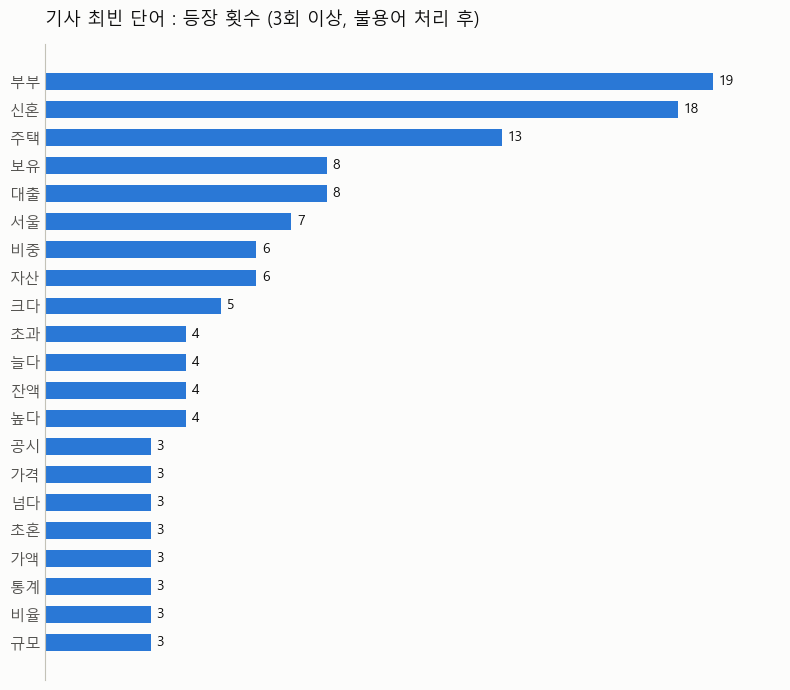

In [ ]:
SURFACE, INK, MUTED, BASELINE, BAR = '#fcfcfb', '#0b0b0b', '#52514e', '#c3c2b7', '#2a78d6'

fig, ax = plt.subplots(figsize=(8, 7), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

bars = ax.barh(words, counts, height=0.6, color=BAR)
ax.bar_label(bars, padding=4, color=INK, fontsize=10)      # 막대 끝에 빈도 표시

ax.set_title(f'기사 최빈 단어 : 등장 횟수 ({MIN_COUNT}회 이상, 불용어 처리 후)',
             loc='left', color=INK, fontsize=13, pad=14)
ax.set_xlim(0, max(counts) * 1.1)
ax.set_xticks([])
ax.tick_params(axis='y', length=0, labelsize=11, labelcolor=MUTED)
for side in ['top', 'right', 'bottom']:
    ax.spines[side].set_visible(False)
ax.spines['left'].set_color(BASELINE)                      # 막대가 시작하는 기준선

plt.tight_layout()
plt.show()

---
## 정리

| 과제 | 사용 도구 | 결과 |
|---|---|---|
| 문장/단어 토큰화 | `re`, `nltk.sent_tokenize`, `word_tokenize`, `RegexpTokenizer`, `Mecab.morphs` | `문장부호 + 공백` 구분자로 21문장 분리 (마침표만 쓰면 36조각). 어절 267개 → 형태소 650개 |
| 품사 부착 | `Mecab.pos`, `MeCab.Tagger` | 650개 형태소에 49종 태그 부착. 복합 태그는 분석표현으로 분해 |
| 개체명 인식 | mecab 의미 부류 + 사용자 사전 + `nltk.RegexpParser`, `re` | 인물 2 · 장소 3 · 조직 1, 날짜 · 기간 · 금액 · 비율 · 수량 |
| 원형 복원 | `nltk.RegexpStemmer` / mecab 분석표현 + 규칙 / `Okt(stem=True)` | 어간 추출은 과잉 · 과소 추출 발생, 표제어 추출은 활용형을 기본형으로 통일 |
| 불용어 처리 | 불용 품사 + `nltk.FreqDist` + 불용어 사전 | 650 → 234 → 187 토큰, 최빈어로 기사 주제 확인 |

**공통으로 드러난 한국어 전처리의 어려움**

- 조사 · 어미가 붙는 교착어라 공백만으로는 단어를 나눌 수 없다. 형태소 분석이 모든 단계의 기초가 된다.
- 사전에 없는 단어(신규 기관명)나 중의적인 단어(`이상인`, `유주택`)의 분석 오류가 이후 단계로 그대로 이어진다. → 사용자 사전으로 보완
- 같은 어절도 문맥에 따라 분석이 달라지므로, 문장 전체를 분석한 뒤 어절 단위로 묶어야 한다.